# Flow recommender / ranking evaluation

Reframes the accuracy predictor as a **per-task flow ranker**: for each held-out CC18 task,
rank the candidate flows by predicted accuracy and measure how good the recommended flow is.

Protocol: leave-tasks-out (`GroupKFold` on `task_id`) — the same honest split as the main study.
The (task, flow) matrix is sparse, so a task's candidate set is the flows with a known accuracy
on it, and regret is measured against the best true accuracy within that set.

Methods compared: **model** (the predictor), **global_default** (portfolio baseline — flow that is
best on average across training tasks), and **random**. Beating `global_default` is the real claim.

This notebook is thin orchestration over `openml_flow.run_recommender_evaluation`.

## Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import openml_flow as wf

# --- Configuration -----------------------------------------------------------
CACHE_DIR    = "minimal_cache_cc18"          # DiskCache (OpenML bundle + feature matrices)
FLOWS_CACHE  = "minimal_cache_cc18/flows.joblib"
RESULTS_DIR  = "results_recommender_max"     # ranking CSVs land here
FIG_DIR      = Path(RESULTS_DIR) / "figures"

AGG_MODE     = "max"        # rank "which flow can win on this task"; use "mean" for typical perf
MODEL_NAME   = "extra_trees"  # bagged trees rank best here (see model comparison below)
CV_FOLDS     = 5
KS           = (1, 3, 5, 10)
N_RANDOM_SHUFFLES = 20
MODEL_NAMES  = ["ridge", "random_forest", "extra_trees", "hist_gbrt"]  # for the model comparison
RESULTS_DIR_ALL = "results_recommender_max_allmodels"

# Representations to compare. meta_only cannot rank within-task (all flows on a task share
# one feature vector) — kept as a floor that isolates what the flow text adds.
CONFIGS = [
    {"name": "meta_only",  "text_mode": "none",  "use_task_metafeatures": True},
    {"name": "tfidf_only", "text_mode": "tfidf", "use_task_metafeatures": False},
    {"name": "tfidf_meta", "text_mode": "tfidf", "use_task_metafeatures": True},
    # {"name": "minilm_meta", "text_mode": "minilm", "use_task_metafeatures": True},
]

FIG_DIR.mkdir(parents=True, exist_ok=True)
print("configs:", [c["name"] for c in CONFIGS])

configs: ['meta_only', 'tfidf_only', 'tfidf_meta']


## Load data (OpenML bundle + flow records)

Cached after the first download. Set `OPENML_API_KEY` in the environment if needed.

In [2]:
bundle = wf.load_cc18_from_openml(
    function="predictive_accuracy",
    suite_name="OpenML-CC18",
    cache=wf.DiskCache(CACHE_DIR),
)
flows = wf.load_or_cache_flows(bundle["evals_df"], FLOWS_CACHE)

print("tasks:", bundle["tasks_df"].shape,
      "| eval rows:", bundle["evals_df"].shape,
      "| flows:", len(flows))

tasks: (72, 19) | eval rows: (3785089, 14) | flows: 3073


## Run the recommender evaluation

Writes `ranking_metrics.csv` (means over tasks) and `ranking_metrics_per_task.csv` into `RESULTS_DIR`.

In [3]:
rec = wf.run_recommender_evaluation(
    flows=flows,
    tasks_df=bundle["tasks_df"],
    evals_df=bundle["evals_df"],
    configs=CONFIGS,
    agg_mode=AGG_MODE,
    model_name=MODEL_NAME,
    cv_folds=CV_FOLDS,
    ks=KS,
    n_random_shuffles=N_RANDOM_SHUFFLES,
    cache_dir=CACHE_DIR,
    results_dir=RESULTS_DIR,
)

summary   = rec["summary"]
per_task  = rec["per_task"]
print("results dir:", rec["results_dir"])
summary

Recommender :: meta_only (extra_trees, agg=max) ...


/Users/roman/Documents/Claude/code/workflows/openml_flow.py:1805: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho = float(spearmanr(pred, true).correlation)
/Users/roman/Documents/Claude/code/workflows/openml_flow.py:1805: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho = float(spearmanr(pred, true).correlation)
/Users/roman/Documents/Claude/code/workflows/openml_flow.py:1805: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho = float(spearmanr(pred, true).correlation)
/Users/roman/Documents/Claude/code/workflows/openml_flow.py:1805: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho = float(spearmanr(pred, true).correlation)
/Users/roman/Documents/Claude/code/workflows/openml_flow.py:1805: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rh

Recommender :: tfidf_only (extra_trees, agg=max) ...


Recommender :: tfidf_meta (extra_trees, agg=max) ...


results dir: results_recommender_max


,experiment,method,role,model,n_tasks,spearman_mean,regret@1_mean,nregret@1_mean,hit@1_mean,ndcg@1_mean,...,hit@3_mean,ndcg@3_mean,regret@5_mean,nregret@5_mean,hit@5_mean,ndcg@5_mean,regret@10_mean,nregret@10_mean,hit@10_mean,ndcg@10_mean
0,meta_only,global_default,baseline,,72,0.684612,0.036012,0.094587,0.069444,0.905413,...,0.250000,0.908848,0.004863,0.015769,0.361111,0.918516,0.002077,0.006095,0.527778,0.932296
1,meta_only,model,model,extra_trees,72,NaN,0.058942,0.156993,0.000000,0.843007,...,0.055556,0.826514,0.012890,0.031364,0.083333,0.843715,0.004721,0.012827,0.194444,0.826982
2,meta_only,random,baseline,,72,0.002680,0.111934,0.232177,0.009028,0.767823,...,0.034028,0.768450,0.017352,0.044949,0.066667,0.774333,0.008344,0.023409,0.136806,0.785806
3,tfidf_meta,global_default,baseline,,72,0.684612,0.036012,0.094587,0.069444,0.905413,...,0.250000,0.908848,0.004863,0.015769,0.361111,0.918516,0.002077,0.006095,0.527778,0.932296
4,tfidf_meta,model,model,extra_trees,72,0.731390,0.014849,0.031413,0.222222,0.968587,...,0.347222,0.968635,0.003674,0.010034,0.444444,0.968652,0.002435,0.006083,0.611111,0.966528
5,tfidf_meta,random,baseline,,72,0.002680,0.111934,0.232177,0.009028,0.767823,...,0.034028,0.768450,0.017352,0.044949,0.066667,0.774333,0.008344,0.023409,0.136806,0.785806
6,tfidf_only,global_default,baseline,,72,0.684612,0.036012,0.094587,0.069444,0.905413,...,0.250000,0.908848,0.004863,0.015769,0.361111,0.918516,0.002077,0.006095,0.527778,0.932296
7,tfidf_only,model,model,extra_trees,72,0.659049,0.039952,0.102966,0.055556,0.897034,...,0.236111,0.899214,0.007879,0.021956,0.291667,0.907282,0.002922,0.007258,0.541667,0.920356
8,tfidf_only,random,baseline,,72,0.002680,0.111934,0.232177,0.009028,0.767823,...,0.034028,0.768450,0.017352,0.044949,0.066667,0.774333,0.008344,0.023409,0.136806,0.785806


## Headline table: model vs baselines

Lower `nregret@1` is better (0 = always recommends the best flow); higher `hit@k`, `ndcg`, `spearman` are better.

In [4]:
show_cols = ["experiment", "method", "n_tasks", "spearman_mean",
             "nregret@1_mean", "nregret@3_mean", "hit@1_mean", "hit@3_mean", "ndcg@5_mean"]
table = summary[show_cols].copy()
method_order = {"model": 0, "global_default": 1, "random": 2}
table = table.sort_values(
    ["experiment", "method"], key=lambda s: s.map(method_order) if s.name == "method" else s
).reset_index(drop=True)
table.round(4)

,experiment,method,n_tasks,spearman_mean,nregret@1_mean,nregret@3_mean,hit@1_mean,hit@3_mean,ndcg@5_mean
0,meta_only,model,72,NaN,0.1570,0.0743,0.0000,0.0556,0.8437
1,meta_only,global_default,72,0.6846,0.0946,0.0257,0.0694,0.2500,0.9185
2,meta_only,random,72,0.0027,0.2322,0.0765,0.0090,0.0340,0.7743
3,tfidf_meta,model,72,0.7314,0.0314,0.0127,0.2222,0.3472,0.9687
4,tfidf_meta,global_default,72,0.6846,0.0946,0.0257,0.0694,0.2500,0.9185
5,tfidf_meta,random,72,0.0027,0.2322,0.0765,0.0090,0.0340,0.7743
6,tfidf_only,model,72,0.6590,0.1030,0.0349,0.0556,0.2361,0.9073
7,tfidf_only,global_default,72,0.6846,0.0946,0.0257,0.0694,0.2500,0.9185
8,tfidf_only,random,72,0.0027,0.2322,0.0765,0.0090,0.0340,0.7743


### Significance vs the portfolio default

Paired Wilcoxon signed-rank test (tasks paired by `task_id`) of the model vs `global_default` on
`nregret@1`. `win_rate` = fraction of tasks where the model beats the default; `median_diff` is the
median of (model − default) so negative favours the model.

In [5]:
w = rec["wilcoxon"]
sig = w[(w["baseline"] == "global_default") & (w["metric"] == "nregret@1")]
sig = sig[["experiment", "method", "n_tasks", "median_diff", "win_rate", "p_value"]]
sig.sort_values(["experiment", "p_value"]).round(4).reset_index(drop=True)

,experiment,method,n_tasks,median_diff,win_rate,p_value
0,meta_only,model,72,0.0353,0.1806,0.0000
1,tfidf_meta,model,72,-0.0057,0.6389,0.0015
2,tfidf_only,model,72,0.0000,0.0417,0.0912


## Figure 1 — normalized regret@1 by representation and method

The recommender is useful when the **model** bar sits clearly below **global_default**.

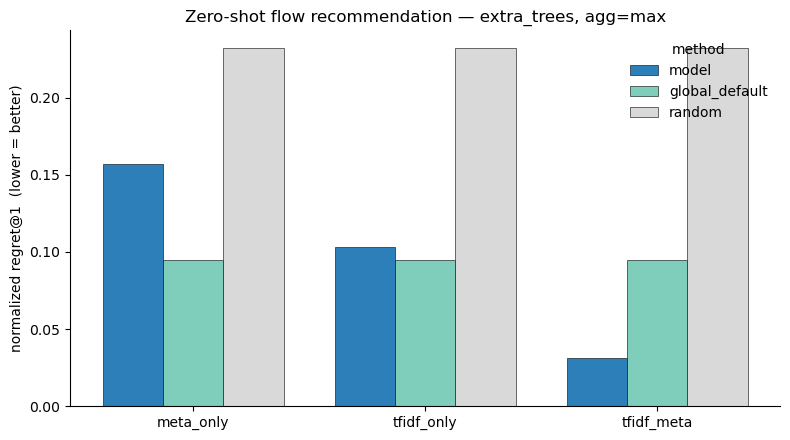

In [6]:
methods = ["model", "global_default", "random"]
colors  = {"model": "#2c7fb8", "global_default": "#7fcdbb", "random": "#d9d9d9"}
exps    = [c["name"] for c in CONFIGS if c["name"] in set(summary["experiment"])]

piv = summary.pivot_table(index="experiment", columns="method", values="nregret@1_mean")
piv = piv.reindex(index=exps, columns=methods)

x = np.arange(len(exps))
w = 0.26
fig, ax = plt.subplots(figsize=(8, 4.5))
for i, m in enumerate(methods):
    ax.bar(x + (i - 1) * w, piv[m].values, width=w, label=m, color=colors[m], edgecolor="black", linewidth=0.4)
ax.set_xticks(x)
ax.set_xticklabels(exps)
ax.set_ylabel("normalized regret@1  (lower = better)")
ax.set_title(f"Zero-shot flow recommendation — {MODEL_NAME}, agg={AGG_MODE}")
ax.legend(title="method", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "regret_at_1.png", dpi=150)
fig.savefig(FIG_DIR / "regret_at_1.pdf")
plt.show()

## Figure 2 — hit@k curves

Probability the truly-best flow is within the top-k recommended, as a function of k.

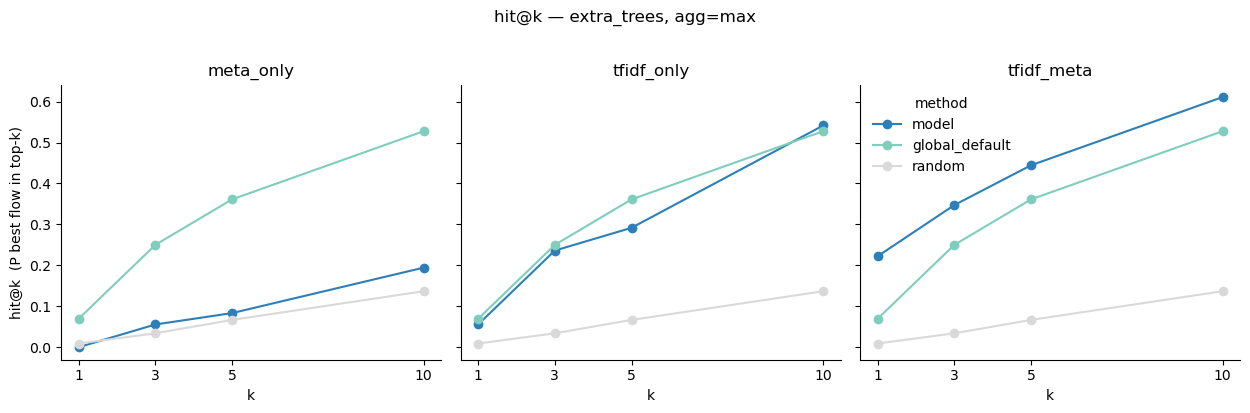

In [7]:
fig, axes = plt.subplots(1, len(exps), figsize=(4.2 * len(exps), 4), sharey=True)
axes = np.atleast_1d(axes)
for ax, exp in zip(axes, exps):
    sub = summary[summary["experiment"] == exp]
    for m in methods:
        row = sub[sub["method"] == m]
        if row.empty:
            continue
        ys = [float(row[f"hit@{k}_mean"].iloc[0]) for k in KS]
        ax.plot(KS, ys, marker="o", label=m, color=colors[m])
    ax.set_title(exp)
    ax.set_xlabel("k")
    ax.set_xticks(list(KS))
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("hit@k  (P best flow in top-k)")
axes[-1].legend(title="method", frameon=False)
fig.suptitle(f"hit@k — {MODEL_NAME}, agg={AGG_MODE}", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "hit_at_k.png", dpi=150, bbox_inches="tight")
fig.savefig(FIG_DIR / "hit_at_k.pdf", bbox_inches="tight")
plt.show()

## Per-task spread

Regret is an average over tasks; the per-task distribution shows whether the model helps everywhere
or is carried by a few easy tasks. Uses `nregret@1` from `per_task` for the best representation.

best representation (model, lowest nregret@1): tfidf_meta


/var/folders/v4/mgpzl55x2p907x9g5_5hh62h0000gn/T/ipykernel_70493/2249333500.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=["model", "global_default"], showmeans=True)


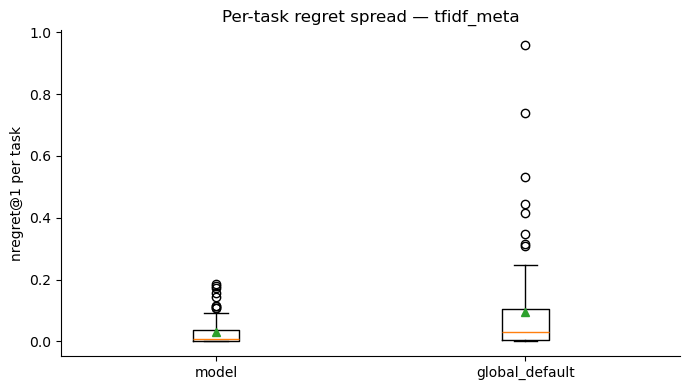

In [8]:
best_exp = (
    summary[summary["method"] == "model"]
    .sort_values("nregret@1_mean").iloc[0]["experiment"]
)
print("best representation (model, lowest nregret@1):", best_exp)

sub = per_task[(per_task["experiment"] == best_exp) & (per_task["method"].isin(["model", "global_default"]))]
fig, ax = plt.subplots(figsize=(7, 4))
data = [sub[sub["method"] == m]["nregret@1"].dropna().values for m in ["model", "global_default"]]
ax.boxplot(data, labels=["model", "global_default"], showmeans=True)
ax.set_ylabel("nregret@1 per task")
ax.set_title(f"Per-task regret spread — {best_exp}")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "per_task_regret_box.png", dpi=150)
plt.show()

## Warm-start: how much search does the ranking save?

Treat each method's ranking as a greedy search: evaluate flows top-down and stop when within
`warm_start_eps` accuracy of the best. `trials_to_target` is how many flow evaluations that takes.
The speedup vs `random` is the headline "AutoML search saved" number.

In [9]:
tt = rec["trials_to_target"]
cols = ["experiment", "method", "trials_to_target_mean", "trials_to_target_median", "max_trials", "n_tasks"]
tt_show = tt[cols].sort_values(
    ["experiment", "method"],
    key=lambda s: s.map({"model": 0, "global_default": 1, "random": 2}) if s.name == "method" else s,
).reset_index(drop=True)

# speedup = random trials / method trials, per experiment
piv_tt = tt.pivot_table(index="experiment", columns="method", values="trials_to_target_mean")
speedup = pd.DataFrame({
    "model_speedup_vs_random": piv_tt["random"] / piv_tt["model"],
    "model_speedup_vs_default": piv_tt["global_default"] / piv_tt["model"],
}).round(2)
print("trials to within {:.1%} of best (fewer = better):".format(rec["trials_to_target"]["eps_abs"].iloc[0]))
display(tt_show.round(3))
print("\nspeedup (x fewer trials):")
display(speedup)

trials to within 1.0% of best (fewer = better):


,experiment,method,trials_to_target_mean,trials_to_target_median,max_trials,n_tasks
0,meta_only,model,7.500,4.0,452,72
1,meta_only,global_default,3.181,1.0,452,72
2,meta_only,random,10.847,6.5,452,72
3,tfidf_meta,model,2.208,1.0,452,72
4,tfidf_meta,global_default,3.181,1.0,452,72
5,tfidf_meta,random,10.847,6.5,452,72
6,tfidf_only,model,4.028,1.5,452,72
7,tfidf_only,global_default,3.181,1.0,452,72
8,tfidf_only,random,10.847,6.5,452,72



speedup (x fewer trials):


,model_speedup_vs_random,model_speedup_vs_default
experiment,,
meta_only,1.45,0.42
tfidf_meta,4.91,1.44
tfidf_only,2.69,0.79


## Figure 3 — warm-start regret curves

Mean normalized regret as a function of the number of flows evaluated. A good ranker's curve
drops to ~0 far faster than `random`.

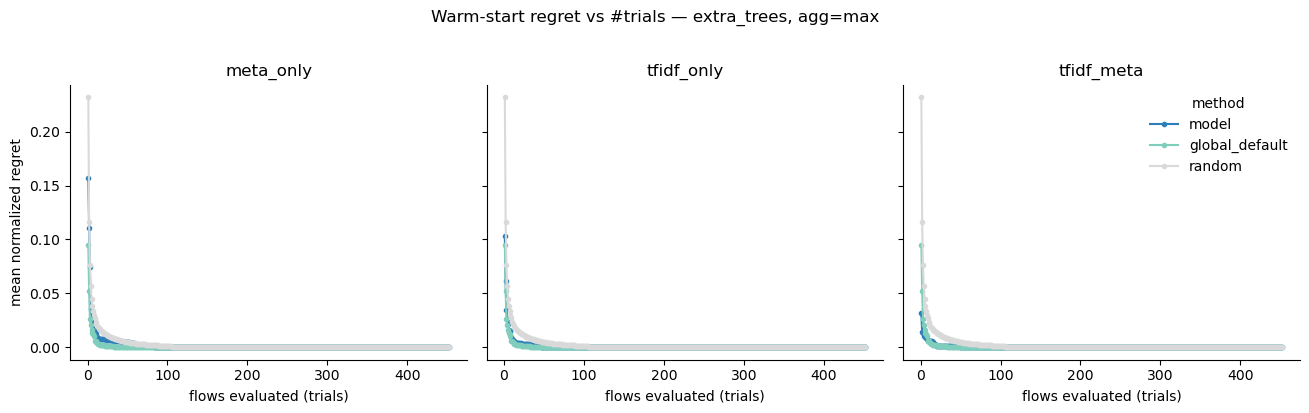

In [10]:
curve = rec["warm_start_curve"]
fig, axes = plt.subplots(1, len(exps), figsize=(4.4 * len(exps), 4), sharey=True)
axes = np.atleast_1d(axes)
for ax, exp in zip(axes, exps):
    sub = curve[curve["experiment"] == exp]
    for m in methods:
        cm = sub[sub["method"] == m].sort_values("trial")
        if cm.empty:
            continue
        ax.plot(cm["trial"], cm["nregret_mean"], marker=".", label=m, color=colors[m])
    ax.set_title(exp)
    ax.set_xlabel("flows evaluated (trials)")
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("mean normalized regret")
axes[-1].legend(title="method", frameon=False)
fig.suptitle(f"Warm-start regret vs #trials \u2014 {MODEL_NAME}, agg={AGG_MODE}", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "warm_start_curve.png", dpi=150, bbox_inches="tight")
fig.savefig(FIG_DIR / "warm_start_curve.pdf", bbox_inches="tight")
plt.show()

## Model comparison — all 4 regressors

The ranker is model-agnostic, so compare all four regressors in one run (`model_names=...`).
Bagged trees (`extra_trees`, `random_forest`) rank flows best; boosting (`hist_gbrt`) and linear
(`ridge`) trail and don't significantly beat the portfolio default. Writes to `RESULTS_DIR_ALL`.

Recommender :: meta_only (ridge+random_forest+extra_trees+hist_gbrt, agg=max) ...


/Users/roman/Documents/Claude/code/workflows/openml_flow.py:1805: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho = float(spearmanr(pred, true).correlation)
/Users/roman/Documents/Claude/code/workflows/openml_flow.py:1805: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho = float(spearmanr(pred, true).correlation)
/Users/roman/Documents/Claude/code/workflows/openml_flow.py:1805: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho = float(spearmanr(pred, true).correlation)
/Users/roman/Documents/Claude/code/workflows/openml_flow.py:1805: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho = float(spearmanr(pred, true).correlation)
/Users/roman/Documents/Claude/code/workflows/openml_flow.py:1805: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rh

Recommender :: tfidf_only (ridge+random_forest+extra_trees+hist_gbrt, agg=max) ...


Recommender :: tfidf_meta (ridge+random_forest+extra_trees+hist_gbrt, agg=max) ...


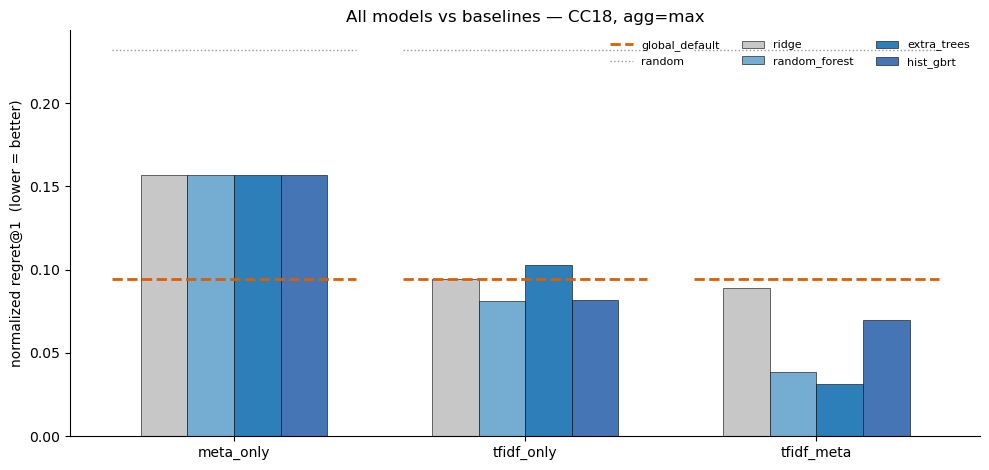

,experiment,method,role,spearman_mean,nregret@1_mean,hit@1_mean,ndcg@5_mean
0,meta_only,ridge,model,NaN,0.1570,0.0000,0.8437
1,meta_only,random_forest,model,NaN,0.1570,0.0000,0.8437
2,meta_only,extra_trees,model,NaN,0.1570,0.0000,0.8437
3,meta_only,hist_gbrt,model,NaN,0.1570,0.0000,0.8437
4,meta_only,global_default,baseline,0.6846,0.0946,0.0694,0.9185
5,meta_only,random,baseline,0.0027,0.2322,0.0090,0.7743
6,tfidf_meta,ridge,model,0.6466,0.0892,0.0556,0.9314
7,tfidf_meta,random_forest,model,0.7053,0.0383,0.1806,0.9555
8,tfidf_meta,extra_trees,model,0.7314,0.0314,0.2222,0.9687
9,tfidf_meta,hist_gbrt,model,0.7058,0.0698,0.0556,0.9473


In [11]:
rec_all = wf.run_recommender_evaluation(
    flows=flows, tasks_df=bundle["tasks_df"], evals_df=bundle["evals_df"],
    configs=CONFIGS, agg_mode=AGG_MODE, model_names=MODEL_NAMES,
    cv_folds=CV_FOLDS, ks=KS, n_random_shuffles=N_RANDOM_SHUFFLES,
    cache_dir=CACHE_DIR, results_dir=RESULTS_DIR_ALL,
)
sa = rec_all["summary"]
mcol = {"ridge": "#c7c7c7", "random_forest": "#74add1", "extra_trees": "#2c7fb8", "hist_gbrt": "#4575b4"}
exps_all = [c["name"] for c in CONFIGS if c["name"] in set(sa["experiment"])]

fig, ax = plt.subplots(figsize=(10, 4.8))
x = np.arange(len(exps_all)); w_ = 0.16
for i, m in enumerate(MODEL_NAMES):
    vals = [float(sa[(sa.experiment == e) & (sa.method == m)]["nregret@1_mean"].iloc[0]) for e in exps_all]
    ax.bar(x + (i - 1.5) * w_, vals, width=w_, label=m, color=mcol[m], edgecolor="black", linewidth=0.4)
for ei, e in enumerate(exps_all):
    gd = float(sa[(sa.experiment == e) & (sa.method == "global_default")]["nregret@1_mean"].iloc[0])
    rnd = float(sa[(sa.experiment == e) & (sa.method == "random")]["nregret@1_mean"].iloc[0])
    ax.hlines(gd, x[ei] - 0.42, x[ei] + 0.42, color="#d95f02", lw=2, ls="--", label="global_default" if ei == 0 else None)
    ax.hlines(rnd, x[ei] - 0.42, x[ei] + 0.42, color="#999999", lw=1, ls=":", label="random" if ei == 0 else None)
ax.set_xticks(x); ax.set_xticklabels(exps_all)
ax.set_ylabel("normalized regret@1  (lower = better)")
ax.set_title(f"All models vs baselines \u2014 CC18, agg={AGG_MODE}")
ax.legend(ncol=3, frameon=False, fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
(Path(RESULTS_DIR_ALL) / "figures").mkdir(parents=True, exist_ok=True)
fig.savefig(Path(RESULTS_DIR_ALL) / "figures" / "regret_at_1_allmodels.png", dpi=150)
fig.savefig(Path(RESULTS_DIR_ALL) / "figures" / "regret_at_1_allmodels.pdf")
plt.show()

order = {"ridge": 0, "random_forest": 1, "extra_trees": 2, "hist_gbrt": 3, "global_default": 4, "random": 5}
cmp_cols = ["experiment", "method", "role", "spearman_mean", "nregret@1_mean", "hit@1_mean", "ndcg@5_mean"]
sa.sort_values(["experiment", "method"], key=lambda s: s.map(order) if s.name == "method" else s)[cmp_cols].round(4).reset_index(drop=True)

## Notes

- `meta_only` is expected to underperform: with no flow-level features every flow on a task shares
  one feature vector, so the model cannot rank within-task. It isolates what the flow text adds.
- Switch `AGG_MODE` to `"mean"` to rank by typical rather than best-case accuracy.
- Outputs written to `RESULTS_DIR`: `ranking_metrics.csv`, `ranking_metrics_per_task.csv`,
  `warm_start_curve.csv`, `warm_start_trials_to_target.csv` (+ figures under `figures/`).